# Denoising Autoencoder (Rectangular Occlusion) on Oxford-IIIT Pet — Optuna

Plain convolutional autoencoder with **no skip connections**, ported from Keras to PyTorch. The encoder uses two stages, and a separately configurable bottleneck produces the 32×32 latent representation for 128×128 inputs.

## Plan
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Imports, config (image size, noise level, epochs), device |
| 2 | Data | Load the repository's local Oxford-IIIT Pet images and official train / val / test splits |
| 3 | Corruption | Runtime black rectangular occlusions following the assignment rule; visual sanity check |
| 4 | Model | No-skip convolutional autoencoder with a configurable 32×32 bottleneck |
| 5 | Train | Adam + weighted L1/SSIM loss, fresh noise every batch, track train/val loss |
| 6 | Curves | Plot loss, pick best epoch |
| 7 | Test | PSNR and SSIM on the held-out test split: noisy vs. denoised |
| 8 | Visuals | Noisy / denoised / clean grid |
| 9 | Severity evaluation | Evaluate the assignment's low, medium, and high occlusion settings |
| 10 | Save | Save and reload weights and selected Optuna parameters |
| 11 | Save | Save and reload weights |

**Corruption rule:** every training image receives one to three black rectangles that jointly cover 10% to 35% of the image area.


## 1. Setup

In [1]:
!pip install -q torchmetrics scipy optuna wandb

import gc, time, random, json
from pathlib import Path
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import optuna
import wandb
from optuna.trial import TrialState
from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.functional import structural_similarity_index_measure

# ---------------- config ----------------
IMG_SIZE    = 128      # the article uses 240; 128 is faster and lighter on memory
BATCH_SIZE  = 32
EPOCHS      = 30
TRIALS      = 20
TRIAL_EPOCHS = 8

# Explicit Optuna search space
OPTUNA_SEARCH_SPACE = {
    "batch_size": [16, 32, 64],
    "base_channels": [32, 48, 64],
    "bottleneck_channels": [32, 64, 96, 128],
    "learning_rate": {"low": 1e-4, "high": 3e-3, "log": True},
    "alpha": {"low": 0.60, "high": 0.95},
}
LR          = 1e-3
TRAIN_OCCLUSION_RANGE = (0.10, 0.35)
TRAIN_RECTANGLE_COUNTS = [1, 2, 3]
SEED        = 42
NUM_WORKERS = 2
WANDB_PROJECT = "genai-assignment-1"
WANDB_RUN_NAME = "dae-occlusion-optuna"
# ----------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

wandb_run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN_NAME,
    config={
        "corruption": "rectangular_occlusion", "image_size": IMG_SIZE,
        "epochs": EPOCHS, "optuna_trials": TRIALS, "trial_epochs": TRIAL_EPOCHS,
        "seed": SEED, "train_occlusion_range": TRAIN_OCCLUSION_RANGE,
        "train_rectangle_counts": TRAIN_RECTANGLE_COUNTS, "search_space": OPTUNA_SEARCH_SPACE,
    },
)


/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Device: cuda


wandb: Currently logged in as: i230510 (i230510-fast-nuces-islamabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Data — local Oxford-IIIT Pet dataset
Images and official split manifests are read from the repository's `research/datasets` folder. This avoids downloading another copy from torchvision.


In [2]:
# Find the repository root from either the repo root or research/notebooks as the Jupyter working directory.
_here = Path.cwd().resolve()
_repo_candidates = [_here, *_here.parents]
REPO_ROOT = next(
    (p for p in _repo_candidates if (p / "research/datasets/oxford-iiit-pet/images").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find research/datasets/oxford-iiit-pet/images. "
        "Run this notebook from within the repository."
    )

PET_IMAGES_DIR = REPO_ROOT / "research/datasets/oxford-iiit-pet/images"
SPLIT_MANIFEST = REPO_ROOT / "research/split_manifest_official.json"
if not SPLIT_MANIFEST.is_file():
    raise FileNotFoundError(f"Official split manifest not found: {SPLIT_MANIFEST}")
with SPLIT_MANIFEST.open() as f:
    split_manifest = json.load(f)

class LocalPetImages(Dataset):
    """Clean Oxford-IIIT Pet images loaded from the repository's dataset folder."""
    def __init__(self, filenames, transform):
        self.paths = [PET_IMAGES_DIR / name for name in filenames]
        missing = [path for path in self.paths if not path.is_file()]
        if missing:
            raise FileNotFoundError(f"Missing dataset image, for example: {missing[0]}")
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            clean = self.transform(image.convert("RGB"))
        # The training code ignores labels; return a placeholder for its existing batch format.
        return clean, 0

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),            # float in [0, 1], shape (3, H, W)
])

train_ds = LocalPetImages(split_manifest["train"], tfm)
val_ds   = LocalPetImages(split_manifest["val"], tfm)
test_ds  = LocalPetImages(split_manifest["test"], tfm)
print(f"Dataset: {PET_IMAGES_DIR}")
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# labels are ignored: the target is the clean image itself
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


Dataset: /home/zaifi/genai-assignment-1/research/datasets/oxford-iiit-pet/images
train=2944  val=736  test=3669


## 3. Rectangular occlusion

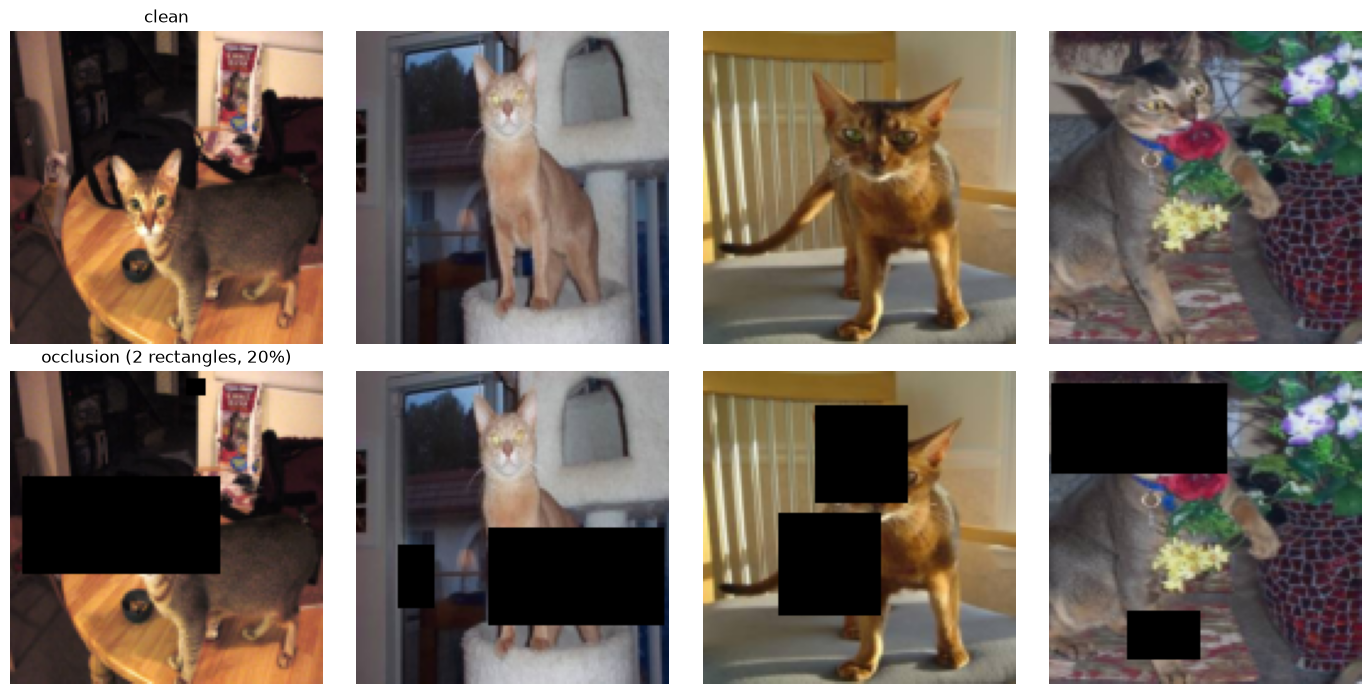

In [3]:
def add_rectangular_occlusion(x, coverage_range=TRAIN_OCCLUSION_RANGE, rectangle_counts=TRAIN_RECTANGLE_COUNTS, target_coverage=None, num_rectangles=None, generator=None):
    """Mask each image with one to three nonoverlapping black rectangles."""
    batch, _, height, width = x.shape
    occluded = x.clone()
    for image_index in range(batch):
        coverage = target_coverage
        if coverage is None:
            coverage = torch.empty((), device=x.device).uniform_(*coverage_range, generator=generator).item()
        rectangles = num_rectangles
        if rectangles is None:
            count_index = torch.randint(len(rectangle_counts), (), device=x.device, generator=generator).item()
            rectangles = rectangle_counts[count_index]
        areas = torch.rand(rectangles, device=x.device, generator=generator)
        areas = areas / areas.sum() * round(coverage * height * width)
        occupied = torch.zeros(height, width, dtype=torch.bool, device=x.device)
        for area in areas:
            aspect = torch.empty((), device=x.device).uniform_(0.5, 2.0, generator=generator).item()
            rect_height = min(height, max(1, round((area.item() / aspect) ** 0.5)))
            rect_width = min(width, max(1, round(area.item() / rect_height)))
            for _ in range(50):
                top = torch.randint(height - rect_height + 1, (), device=x.device, generator=generator).item()
                left = torch.randint(width - rect_width + 1, (), device=x.device, generator=generator).item()
                region = occupied[top:top + rect_height, left:left + rect_width]
                if not region.any():
                    occluded[image_index, :, top:top + rect_height, left:left + rect_width] = 0.0
                    occupied[top:top + rect_height, left:left + rect_width] = True
                    break
    return occluded

# visual sanity check
x, _ = next(iter(test_loader))
x = x[:4].to(device)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    ax[0, i].imshow(x[i].permute(1, 2, 0).cpu());                              ax[0, i].axis("off")
    ax[1, i].imshow(add_rectangular_occlusion(x, target_coverage=0.20, num_rectangles=2)[i].permute(1, 2, 0).cpu()); ax[1, i].axis("off")
ax[0, 0].set_title("clean"); ax[1, 0].set_title("occlusion (2 rectangles, 20%)")
plt.tight_layout(); plt.show()

## 4. Model
The encoder has two two-convolution stages. In each stage, the first convolution changes the channel width while preserving spatial size, and the second keeps the width while halving spatial size. A separate bottleneck convolution sets the latent channel count at 32×32 resolution. The two-stage decoder reverses the encoder widths while upsampling to the original resolution, with no skip connections.


In [4]:
class DenoisingAE(nn.Module):
    def __init__(self, base_channels=64, bottleneck_channels=128):
        super().__init__()
        c1 = base_channels
        c2 = base_channels * 2

        # Each stage first changes channels at fixed resolution, then downsamples.
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(c1, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )

        # The bottleneck width is searched independently from encoder width.
        self.bottleneck = nn.Sequential(
            nn.Conv2d(c2, bottleneck_channels, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Mirror the encoder without concatenating any encoder features.
        self.dec2 = nn.Sequential(
            nn.Conv2d(bottleneck_channels, c2, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c1, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(c1, c1, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        return self.bottleneck(self.enc2(self.enc1(x)))

    def forward(self, x):
        z = self.encode(x)  # (B, bottleneck_channels, H/4, W/4)
        x = F.interpolate(z, scale_factor=2, mode="bilinear")
        x = self.dec2(x)
        x = F.interpolate(x, scale_factor=2, mode="bilinear")
        return self.dec1(x)

model = DenoisingAE(base_channels=64).to(device)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    print("Bottleneck:", tuple(model.encode(dummy).shape), "| Output:", tuple(model(dummy).shape))


DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (dec2): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (dec1): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 3, k

Bottleneck: (1, 128, 32, 32) | Output: (1, 3, 128, 128)


## 5. Optuna search and final training

Optuna minimizes the validation value of the same weighted L1 + (1 − SSIM) loss used for training. The search space is declared explicitly in `OPTUNA_SEARCH_SPACE`: batch size `{16, 32, 64}`, base channels `{32, 48, 64}`, bottleneck channels `{32, 64, 96, 128}`, learning rate `1e-4` to `3e-3` on a log scale, and loss weight `alpha` from `0.60` to `0.95`. Trials use a short schedule; the winning configuration is then trained for the original 30 epochs, with the best validation checkpoint retained. Validation noise is fixed across epochs and trials for a fair comparison.

[I 2026-10-04 09:46:03,951] Using an existing study with `study_name='dae_occlusion_optuna'` instead of creating a new one.
/home/zaifi/genai-assignment-1/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


Trial 001 | epoch 01/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.2113 val=0.1586
Trial 001 | epoch 02/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1457 val=0.1353
Trial 001 | epoch 03/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1303 val=0.1237
Trial 001 | epoch 04/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1221 val=0.1175
Trial 001 | epoch 05/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1177 val=0.1169
Trial 001 | epoch 06/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1142 val=0.1118
Trial 001 | epoch 07/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1117 val=0.1112
Trial 001 | epoch 08/8 | batch=32 base=32 bottleneck=64 alpha=0.939 lr=0.00011 | train=0.1108 val=0.1078


[I 2026-10-04 09:47:37,614] Trial 1 finished with value: 0.10776641997306244 and parameters: {'batch_size': 32, 'base_channels': 32, 'bottleneck_channels': 64, 'lr': 0.00010725209743172001, 'alpha': 0.939468448256698}. Best is trial 1 with value: 0.10776641997306244.


Trial 002 | epoch 01/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.2244 val=0.1782
Trial 002 | epoch 02/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1634 val=0.1510
Trial 002 | epoch 03/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1441 val=0.1370
Trial 002 | epoch 04/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1316 val=0.1254
Trial 002 | epoch 05/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1246 val=0.1199
Trial 002 | epoch 06/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1221 val=0.1183
Trial 002 | epoch 07/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1172 val=0.1125
Trial 002 | epoch 08/8 | batch=16 base=64 bottleneck=96 alpha=0.728 lr=0.00027 | train=0.1151 val=0.1112


[I 2026-10-04 09:49:39,249] Trial 2 finished with value: 0.1112394179015056 and parameters: {'batch_size': 16, 'base_channels': 64, 'bottleneck_channels': 96, 'lr': 0.00027010527749605503, 'alpha': 0.7282266451527921}. Best is trial 1 with value: 0.10776641997306244.


...

Trial 019 | epoch 01/8 | batch=64 base=32 bottleneck=32 alpha=0.934 lr=0.00059 | train=0.2105 val=0.1569
Trial 019 | epoch 02/8 | batch=64 base=32 bottleneck=32 alpha=0.934 lr=0.00059 | train=0.1438 val=0.1348


[I 2026-10-04 10:14:10,695] Trial 19 pruned. 


Trial 020 | epoch 01/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.1391 val=0.1058
Trial 020 | epoch 02/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0950 val=0.0854
Trial 020 | epoch 03/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0806 val=0.0767
Trial 020 | epoch 04/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0760 val=0.0720
Trial 020 | epoch 05/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0720 val=0.0707
Trial 020 | epoch 06/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0716 val=0.0703
Trial 020 | epoch 07/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0688 val=0.0667
Trial 020 | epoch 08/8 | batch=16 base=64 bottleneck=128 alpha=0.931 lr=0.00053 | train=0.0668 val=0.0660


[I 2026-10-04 10:16:14,067] Trial 20 finished with value: 0.06598974626673304 and parameters: {'batch_size': 16, 'base_channels': 64, 'bottleneck_channels': 128, 'lr': 0.0005286840659245586, 'alpha': 0.9310773726787802}. Best is trial 18 with value: 0.06142861776701782.


Complete trials: 14 | pruned trials: 6
Best validation loss: 0.06142861776701782
Best parameters: {'batch_size': 16, 'base_channels': 32, 'bottleneck_channels': 64, 'lr': 0.001457695100367033, 'alpha': 0.9445983341902341}


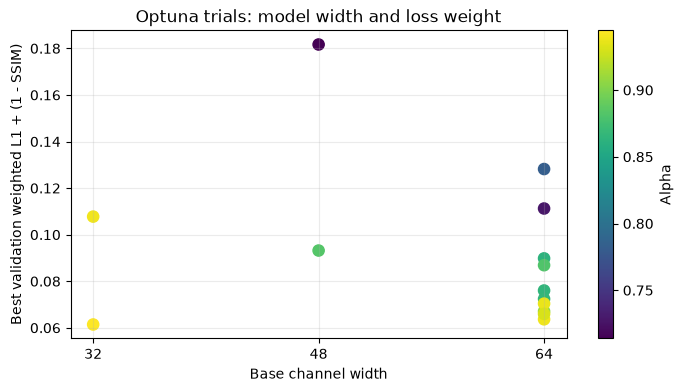

Epoch 01/30 train=0.1305 val=0.1006 (11s)
Epoch 02/30 train=0.0905 val=0.0838 (11s)
Epoch 03/30 train=0.0783 val=0.0727 (11s)
Epoch 04/30 train=0.0734 val=0.0743 (11s)
Epoch 05/30 train=0.0710 val=0.0682 (11s)
Epoch 06/30 train=0.0687 val=0.0682 (11s)
Epoch 07/30 train=0.0678 val=0.0653 (11s)
Epoch 08/30 train=0.0652 val=0.0630 (11s)
Epoch 09/30 train=0.0648 val=0.0644 (11s)
Epoch 10/30 train=0.0641 val=0.0629 (11s)
Epoch 11/30 train=0.0637 val=0.0611 (11s)
Epoch 12/30 train=0.0635 val=0.0652 (11s)
Epoch 13/30 train=0.0618 val=0.0588 (11s)
Epoch 14/30 train=0.0596 val=0.0588 (11s)
Epoch 15/30 train=0.0596 val=0.0589 (12s)
Epoch 16/30 train=0.0585 val=0.0578 (13s)
Epoch 17/30 train=0.0571 val=0.0559 (12s)
Epoch 18/30 train=0.0569 val=0.0546 (11s)
Epoch 19/30 train=0.0555 val=0.0539 (11s)
Epoch 20/30 train=0.0555 val=0.0544 (11s)
Epoch 21/30 train=0.0562 val=0.0543 (11s)
Epoch 22/30 train=0.0551 val=0.0555 (11s)
Epoch 23/30 train=0.0549 val=0.0525 (11s)
Epoch 24/30 train=0.0543 val=0.054

In [5]:
# Assignment Task 1 loss: alpha * L1 + (1 - alpha) * (1 - SSIM).
def ae_loss(pred, target, alpha):
    l1 = F.l1_loss(pred, target)
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return alpha * l1 + (1.0 - alpha) * (1.0 - ssim)

def run_epoch(model, loader, optimizer=None, alpha=0.8, seed=None):
    training = optimizer is not None
    model.train(training)
    gen = None
    if seed is not None:
        gen = torch.Generator(device=device)
        gen.manual_seed(seed)
    total, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_rectangular_occlusion(clean, generator=gen)
            out = model(noisy)
            loss = ae_loss(out, clean, alpha)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0)
            n += clean.size(0)
    return total / n

def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
    )
    return train_loader, val_loader

def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", OPTUNA_SEARCH_SPACE["batch_size"])
    base_channels = trial.suggest_categorical("base_channels", OPTUNA_SEARCH_SPACE["base_channels"])
    bottleneck_channels = trial.suggest_categorical("bottleneck_channels", OPTUNA_SEARCH_SPACE["bottleneck_channels"])
    lr_space = OPTUNA_SEARCH_SPACE["learning_rate"]
    lr = trial.suggest_float("lr", lr_space["low"], lr_space["high"], log=lr_space["log"])
    alpha_space = OPTUNA_SEARCH_SPACE["alpha"]
    alpha = trial.suggest_float("alpha", alpha_space["low"], alpha_space["high"])
    random.seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)
    torch.manual_seed(SEED + trial.number)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED + trial.number)

    train_loader, val_loader = make_loaders(batch_size)
    trial_model = DenoisingAE(base_channels=base_channels, bottleneck_channels=bottleneck_channels).to(device)
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr)
    best_trial_val = float("inf")
    try:
        for epoch in range(1, TRIAL_EPOCHS + 1):
            train_loss = run_epoch(trial_model, train_loader, optimizer, alpha=alpha)
            val_loss = run_epoch(trial_model, val_loader, alpha=alpha, seed=SEED)
            best_trial_val = min(best_trial_val, val_loss)
            trial.report(val_loss, step=epoch)
            wandb.log({
                "optuna/trial": trial.number, "optuna/epoch": epoch,
                "optuna/train_loss": train_loss, "optuna/validation_loss": val_loss,
                "optuna/best_validation_loss": best_trial_val,
                "optuna/batch_size": batch_size, "optuna/base_channels": base_channels,
                "optuna/bottleneck_channels": bottleneck_channels,
                "optuna/learning_rate": lr, "optuna/alpha": alpha,
            })
            print(
                f"Trial {trial.number:03d} | epoch {epoch:02d}/{TRIAL_EPOCHS} | "
                f"batch={batch_size} base={base_channels} bottleneck={bottleneck_channels} "
                f"alpha={alpha:.3f} lr={lr:.2g} | "
                f"train={train_loss:.4f} val={val_loss:.4f}"
            )
            if trial.should_prune():
                raise optuna.TrialPruned()
        return best_trial_val
    finally:
        del trial_model, optimizer, train_loader, val_loader
        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

STUDY_NAME = "dae_occlusion_optuna"
STORAGE = f"sqlite:///{REPO_ROOT / 'research/notebooks/dae_occlusion_optuna.db'}"
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STORAGE,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=pruner,
)
study.optimize(objective, n_trials=TRIALS)

completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
pruned_trials = [t for t in study.trials if t.state == TrialState.PRUNED]
print(f"Complete trials: {len(completed_trials)} | pruned trials: {len(pruned_trials)}")
print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)
wandb.config.update({f"best_{key}": value for key, value in study.best_params.items()})
wandb.summary["optuna/best_validation_loss"] = study.best_value

# Visualize completed trials by channel width, with color showing alpha.
plt.figure(figsize=(8, 4))
plt.scatter(
    [t.params["base_channels"] for t in completed_trials],
    [t.value for t in completed_trials],
    c=[t.params["alpha"] for t in completed_trials], cmap="viridis", s=65,
)
plt.xticks([32, 48, 64])
plt.xlabel("Base channel width")
plt.ylabel("Best validation weighted L1 + (1 - SSIM)")
plt.title("Optuna trials: model width and loss weight")
plt.colorbar(label="Alpha")
plt.grid(alpha=0.25)
plt.show()

# Retrain the best configuration with the source notebook's full training schedule.
best_params = study.best_params
ALPHA = best_params["alpha"]
LR = best_params["lr"]
BATCH_SIZE = best_params["batch_size"]
BASE_CHANNELS = best_params["base_channels"]
BOTTLENECK_CHANNELS = best_params["bottleneck_channels"]
set_seed(SEED)
train_loader, val_loader = make_loaders(BATCH_SIZE)
model = DenoisingAE(base_channels=BASE_CHANNELS, bottleneck_channels=BOTTLENECK_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {"loss": [], "val_loss": []}
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer, alpha=ALPHA)
    va = run_epoch(model, val_loader, alpha=ALPHA, seed=SEED)
    history["loss"].append(tr)
    history["val_loss"].append(va)
    wandb.log({"epoch": epoch, "train/loss": tr, "validation/loss": va, "learning_rate": LR})
    if va < best_val:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    print(
        f"Epoch {epoch:02d}/{EPOCHS} train={tr:.4f} val={va:.4f} "
        f"({time.time() - t0:.0f}s)"
    )

model.load_state_dict(best_state)
model.to(device).eval()
print(f"Best val loss: {best_val:.4f} | batch={BATCH_SIZE} | base={BASE_CHANNELS} | bottleneck={BOTTLENECK_CHANNELS} | alpha={ALPHA:.3f} | lr={LR:.2g}")


## 6. Loss curves

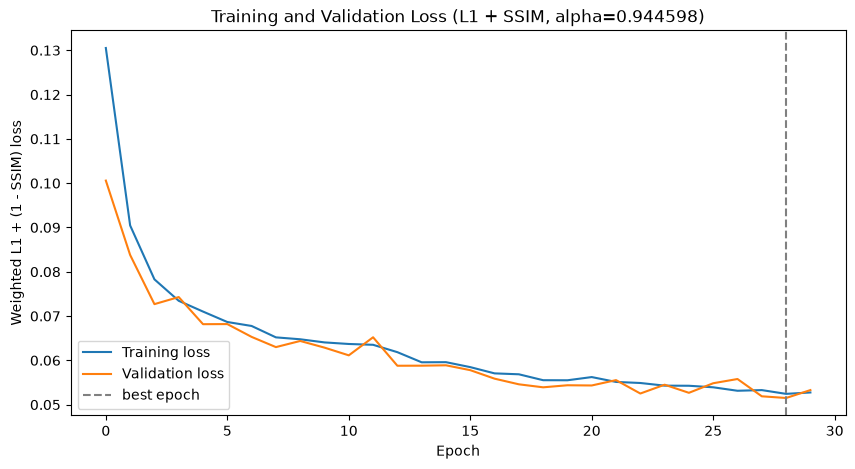

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", label="best epoch")
plt.title(f"Training and Validation Loss (L1 + SSIM, alpha={ALPHA:g})"); plt.xlabel("Epoch"); plt.ylabel("Weighted L1 + (1 - SSIM) loss")
plt.legend(); plt.show()


## 7. Test-set evaluation (PSNR / SSIM)
A fixed seed means the *same* corrupted test images are used every time you run this.

In [7]:
def psnr_batch(a, b):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)          # per-image PSNR, data range [0, 1]

@torch.no_grad()
def evaluate(model, loader, coverage=0.20, rectangles=2, seed=123):
    model.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    ssim_n = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_d = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    p_n, p_d = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_rectangular_occlusion(clean, target_coverage=coverage, num_rectangles=rectangles, generator=gen)
        den   = model(noisy)
        p_n.append(psnr_batch(noisy, clean)); p_d.append(psnr_batch(den, clean))
        ssim_n.update(noisy, clean);          ssim_d.update(den, clean)
    return dict(psnr_noisy=torch.cat(p_n).mean().item(), psnr_denoised=torch.cat(p_d).mean().item(),
                ssim_noisy=ssim_n.compute().item(),      ssim_denoised=ssim_d.compute().item())

res = evaluate(model, test_loader, coverage=0.20, rectangles=2)
print("Occlusion: 2 rectangles, approximately 20% coverage")
print(f"PSNR  noisy: {res['psnr_noisy']:.2f} dB  ->  denoised: {res['psnr_denoised']:.2f} dB")
print(f"SSIM  noisy: {res['ssim_noisy']:.4f}     ->  denoised: {res['ssim_denoised']:.4f}")
wandb.log({
    "test/coverage": 0.20, "test/rectangles": 2,
    **{f"test/{key}": value for key, value in res.items()},
})

Occlusion: 2 rectangles, approximately 20% coverage
PSNR  noisy: 13.35 dB  ->  denoised: 22.72 dB
SSIM  noisy: 0.7591     ->  denoised: 0.7924


## 8. Visual results

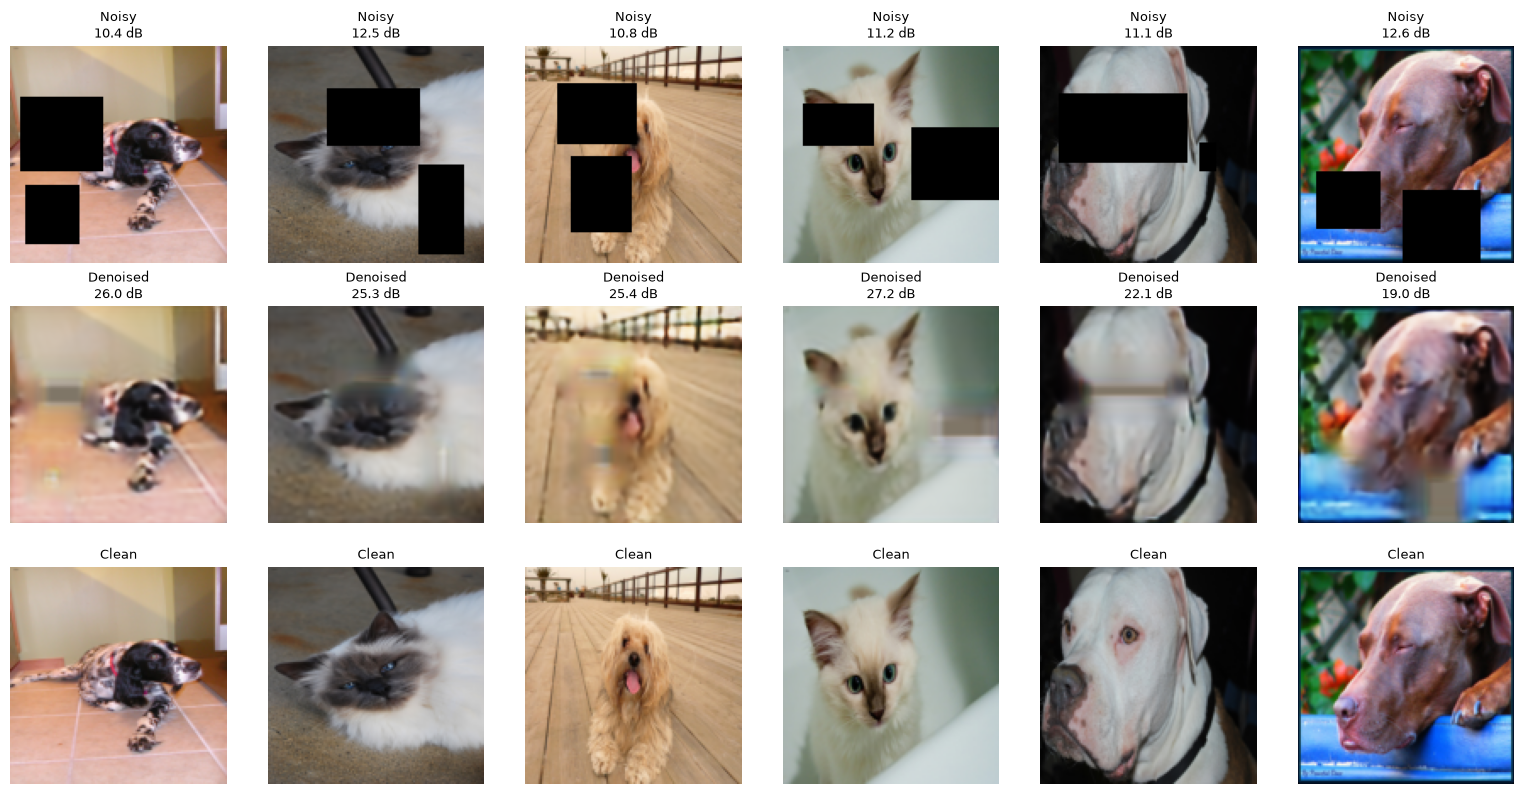

In [8]:
@torch.no_grad()
def show_results(model, dataset, coverage=0.20, rectangles=2, n=6, seed=7):
    model.eval()
    idx = random.Random(seed).sample(range(len(dataset)), n)
    clean = torch.stack([dataset[i][0] for i in idx]).to(device)
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    noisy = add_rectangular_occlusion(clean, target_coverage=coverage, num_rectangles=rectangles, generator=gen)
    den = model(noisy)
    p_n, p_d = psnr_batch(noisy, clean), psnr_batch(den, clean)

    rows = [("Noisy", noisy, p_n), ("Denoised", den, p_d), ("Clean", clean, None)]
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 8))
    for r, (name, imgs, p) in enumerate(rows):
        for c in range(n):
            ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).cpu()); ax[r, c].axis("off")
            if p is not None: ax[r, c].set_title(f"{name}\n{p[c]:.1f} dB", fontsize=9)
            else:             ax[r, c].set_title(name, fontsize=9)
    plt.tight_layout(); plt.show()

show_results(model, test_ds)

## 9. Required occlusion severity sweep
The assignment specifies one, two, and three rectangles with approximately 10%, 20%, and 35% coverage.

coverage≈10%, rectangles=1 | PSNR 16.71 -> 25.30 dB | SSIM 0.878 -> 0.841
coverage≈20%, rectangles=2 | PSNR 13.35 -> 22.72 dB | SSIM 0.759 -> 0.792
coverage≈35%, rectangles=3 | PSNR 11.12 -> 20.53 dB | SSIM 0.609 -> 0.726


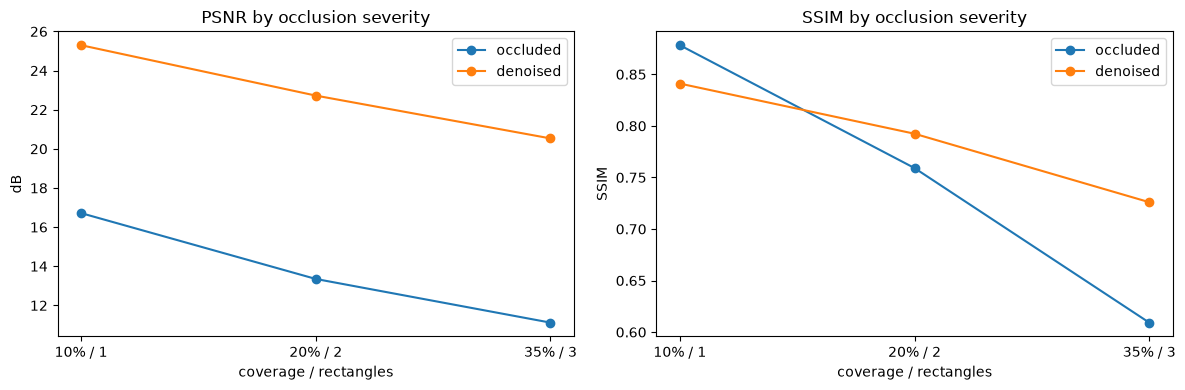

In [9]:
levels = [(0.10, 1), (0.20, 2), (0.35, 3)]
rows = []
for coverage, rectangles in levels:
    r = evaluate(model, test_loader, coverage, rectangles)
    rows.append((f"{coverage:.0%} / {rectangles}", r["psnr_noisy"], r["psnr_denoised"], r["ssim_noisy"], r["ssim_denoised"]))
    print(f"coverage≈{coverage:.0%}, rectangles={rectangles} | PSNR {r['psnr_noisy']:5.2f} -> {r['psnr_denoised']:5.2f} dB | SSIM {r['ssim_noisy']:.3f} -> {r['ssim_denoised']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = [r[0] for r in rows]
ax[0].plot(labels, [r[1] for r in rows], "o-", label="occluded"); ax[0].plot(labels, [r[2] for r in rows], "o-", label="denoised")
ax[0].set(title="PSNR by occlusion severity", xlabel="coverage / rectangles", ylabel="dB"); ax[0].legend()
ax[1].plot(labels, [r[3] for r in rows], "o-", label="occluded"); ax[1].plot(labels, [r[4] for r in rows], "o-", label="denoised")
ax[1].set(title="SSIM by occlusion severity", xlabel="coverage / rectangles", ylabel="SSIM"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Checkpoint

In [10]:
# Save the selected model and Optuna parameters in the repository's research/checkpoints folder.
checkpoint_path = REPO_ROOT / "research/checkpoints/dae_occlusion_optuna_best.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
torch.save({
    "state_dict": model.state_dict(),
    "img_size": IMG_SIZE,
    "occlusion_coverage_range": TRAIN_OCCLUSION_RANGE,
    "rectangle_counts": TRAIN_RECTANGLE_COUNTS,
    "batch_size": BATCH_SIZE,
    "base_channels": BASE_CHANNELS,
    "bottleneck_channels": BOTTLENECK_CHANNELS,
    "alpha": ALPHA,
    "learning_rate": LR,
    "best_val_loss": best_val,
    "optuna_best_params": best_params,
}, checkpoint_path)
print("Saved:", checkpoint_path)

Saved: /home/zaifi/genai-assignment-1/research/checkpoints/dae_occlusion_optuna_best.pt


## 11. Reload and verify

In [11]:
# Reload and verify the selected architecture and weights.
ckpt = torch.load(checkpoint_path, map_location=device)
model2 = DenoisingAE(
    base_channels=ckpt["base_channels"],
    bottleneck_channels=ckpt["bottleneck_channels"],
).to(device)
model2.load_state_dict(ckpt["state_dict"])
model2.eval()
print("Reloaded OK. Test PSNR:", round(evaluate(model2, test_loader, 0.20, 2)["psnr_denoised"], 2), "dB")
model_artifact = wandb.Artifact(
    name=f"{WANDB_RUN_NAME}-model", type="model",
    metadata={"best_validation_loss": best_val, **best_params},
)
model_artifact.add_file(str(checkpoint_path))
wandb.log_artifact(model_artifact)
wandb.finish()


Reloaded OK. Test PSNR: 22.72 dB


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
optuna/alpha,██▁▁▁▆▆▃▃▃▁▁▁▆▆▆▃▃▅▅▆▆▆▆▇▆▆▆▆▆█████▄████
optuna/base_channels,▁▁▁▁▁███▅▅███▅▅████████████████████▁▁▁██
optuna/batch_size,▃▃▃▃▃▁▃▃▃▃▃▃██████▃█▁▁▁▁▁▁▁▁▁▃▃▁▁▁▁▁▁▁▁▁
optuna/best_validation_loss,▄▄▃▃▄▃▄▃▂▂▅▄▇▆▆█▃▂▃▃▂▂▂▃▂▂▂▁▁▃▂▁▃▂▂▁▃▁▁▁
optuna/bottleneck_channels,▃▃▃▃▆█████▃▃▃▃▃▆▃▁▁▁▁▁▃▃▃▆▆▆▃▃▃▃▃▃▃▃▃▃██
optuna/epoch,▁▂▇█▁▄▅▁▂▃▆▂▃▅█▆█▂▂▇█▂▄▁▂█▁▇▁▂▂▃▄▆▇▅▁▂▄▃
optuna/learning_rate,▁▁▁▁▁▁▁███▁▁▁▁▄▂▂▂▂▆▁▁▁▁▁▄▄▄▄▄▂▂▄▃▃▃▅▅▅▂
optuna/train_loss,▃▂▃▃▄▂▂▄▃▃█▄▆▄▄▁▁▂▂▂▂▂▂▁▁▃▂▁▁▁▁▁▃▁▂▁▁▅▃▁
+10,...


## Next steps
- Compare the low, medium, and high occlusion results with the other specialist autoencoders.
- Make a U-Net variant by concatenating encoder feature maps into the decoder, then compare it against this no-skip baseline.
- Compare the winning Optuna configuration with the fixed `batch_size=32`, `base_channels=64`, `bottleneck_channels=128`, `alpha=0.8`, `lr=1e-3` baseline.